## Insurance Claim  Prediction

**Loading  the dataset**

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('data_set.csv')

**Displaying  basic information about the dataset**

In [4]:
print("--- Dataset Info ---")
df.info()

print("\n--- Missing Values Check ---")
print(df.isnull().sum()[df.isnull().sum() > 0]) # Only shows columns with missing values

print("\n--- First 5 Rows ---")
display(df.head())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 595212 entries, 0 to 595211
Data columns (total 59 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              595212 non-null  int64  
 1   target          595212 non-null  int64  
 2   ps_ind_01       595212 non-null  int64  
 3   ps_ind_02_cat   595212 non-null  int64  
 4   ps_ind_03       595212 non-null  int64  
 5   ps_ind_04_cat   595212 non-null  int64  
 6   ps_ind_05_cat   595212 non-null  int64  
 7   ps_ind_06_bin   595212 non-null  int64  
 8   ps_ind_07_bin   595212 non-null  int64  
 9   ps_ind_08_bin   595212 non-null  int64  
 10  ps_ind_09_bin   595212 non-null  int64  
 11  ps_ind_10_bin   595212 non-null  int64  
 12  ps_ind_11_bin   595212 non-null  int64  
 13  ps_ind_12_bin   595212 non-null  int64  
 14  ps_ind_13_bin   595212 non-null  int64  
 15  ps_ind_14       595212 non-null  int64  
 16  ps_ind_15       595212 non-null  in

,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
0,7,0,2,2,5,1,0,0,1,0,...,9,1,5,8,0,1,1,0,0,1
1,9,0,1,1,7,0,0,0,0,1,...,3,1,1,9,0,1,1,0,1,0
2,13,0,5,4,9,1,0,0,0,1,...,4,2,7,7,0,1,1,0,1,0
3,16,0,0,1,2,0,0,1,0,0,...,2,2,4,9,0,0,0,0,0,0
4,17,0,0,2,0,1,0,1,0,0,...,3,1,1,3,0,0,0,1,1,0


**Checking the distribution of the target variable**

In [5]:
print("--- Target Distribution (%) ---")
print(df['target'].value_counts(normalize=True) * 100)

--- Target Distribution (%) ---
target
0    96.355248
1     3.644752
Name: proportion, dtype: float64


**2. Check for hidden missing values (represented as -1)**

In [6]:
hidden_missing = (df == -1).sum()
print("\n--- Columns with '-1' (Missing Values) ---")
print(hidden_missing[hidden_missing > 0])


--- Columns with '-1' (Missing Values) ---
ps_ind_02_cat       216
ps_ind_04_cat        83
ps_ind_05_cat      5809
ps_reg_03        107772
ps_car_01_cat       107
ps_car_02_cat         5
ps_car_03_cat    411231
ps_car_05_cat    266551
ps_car_07_cat     11489
ps_car_09_cat       569
ps_car_11             5
ps_car_12             1
ps_car_14         42620
dtype: int64


**Separating features (X) and target (y)**

In [7]:
# We drop 'id' because it's just an identifier, not a predictive feature
X = df.drop(['id', 'target'], axis=1)
y = df['target']

print(f"\nFeature set shape (X): {X.shape}")


Feature set shape (X): (595212, 57)


**Preprocessing & Splitting the Data**

In [8]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# 1. Replacing the hidden -1 values with standard NaN so Pandas recognizes them
df.replace(-1, np.nan, inplace=True)

# 2. Droping columns with massive amounts of missing data
cols_to_drop = ['ps_car_03_cat', 'ps_car_05_cat']
df.drop(columns=cols_to_drop, inplace=True)

# Re-define X after dropping columns
X = df.drop(['id', 'target'], axis=1)
y = df['target']

# 3. Impute (fill in) the remaining missing values using the median
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# 4. Train/Test Split
# We use stratify=y to ensure the 96/3 imbalance is perfectly maintained in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")
print("Data preprocessing complete. Ready for modeling!")

Training data shape: (476169, 55)
Testing data shape: (119043, 55)
Data preprocessing complete. Ready for modeling!


## Task-1

### Training the model

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler

# 1. Scale the data (Logistic Regression needs this to perform well)
print("Scaling data...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Train Logistic Regression (Baseline)
print("Training Logistic Regression...")
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Get predictions and probabilities
lr_preds = lr_model.predict(X_test_scaled)
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]

print("\n--- Logistic Regression Performance ---")
print(classification_report(y_test, lr_preds))
print(f"ROC-AUC Score: {roc_auc_score(y_test, lr_probs):.4f}\n")

# 3. Train Random Forest (Advanced)
print("Training Random Forest (this may take a few minutes)...")
# Using max_depth and n_estimators=50 to keep training time reasonable for now
rf_model = RandomForestClassifier(class_weight='balanced', n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)
rf_model.fit(X_train, y_train) # Tree models don't need scaled data

# Get predictions and probabilities
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

print("\n--- Random Forest Performance ---")
print(classification_report(y_test, rf_preds))
print(f"ROC-AUC Score: {roc_auc_score(y_test, rf_probs):.4f}")

Scaling data...
Training Logistic Regression...

--- Logistic Regression Performance ---
              precision    recall  f1-score   support

           0       0.97      0.63      0.76    114704
           1       0.05      0.54      0.10      4339

    accuracy                           0.62    119043
   macro avg       0.51      0.58      0.43    119043
weighted avg       0.94      0.62      0.74    119043

ROC-AUC Score: 0.6207

Training Random Forest (this may take a few minutes)...

--- Random Forest Performance ---
              precision    recall  f1-score   support

           0       0.97      0.73      0.84    114704
           1       0.06      0.42      0.10      4339

    accuracy                           0.72    119043
   macro avg       0.51      0.58      0.47    119043
weighted avg       0.94      0.72      0.81    119043

ROC-AUC Score: 0.6184


### Task-2

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Creating a dataframe of our test predictions for easy plotting
viz_df = pd.DataFrame({
    'Probability': lr_probs,
    'Actual_Claim': y_test
})

GRAPH 1: Distribution of Customer Claim Probabilities 

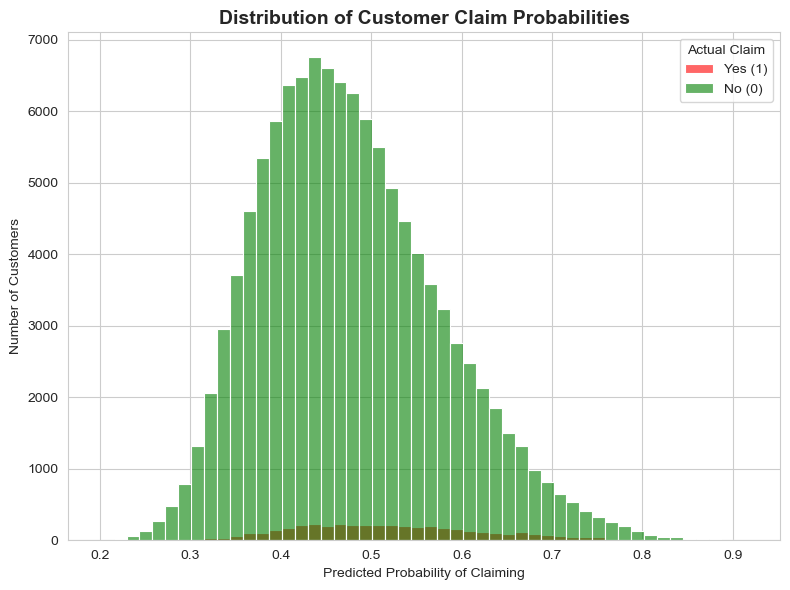

In [11]:
plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")

sns.histplot(data=viz_df, x='Probability', hue='Actual_Claim', bins=50, 
             palette=['green', 'red'], alpha=0.6)

plt.title('Distribution of Customer Claim Probabilities', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Probability of Claiming')
plt.ylabel('Number of Customers')
plt.legend(title='Actual Claim', labels=['Yes (1)', 'No (0)'])

plt.tight_layout()
plt.show()

### **Graph 1 Interpretation: Claim Probability Distribution**

This histogram illustrates the spread of predicted claim probabilities across our customer base. Because the model utilized balanced class weights to counter the extreme 96% class imbalance, the baseline probability was mathematically shifted upward, resulting in a normal-like distribution peaking around 0.45. 

Crucially, we can observe the model's predictive power by comparing the red distribution (Actual Claims) to the green distribution (No Claims). The red distribution is noticeably thicker on the right side and extends further toward higher probabilities. This confirms that the model is successfully working: it correctly assigns higher risk scores to the specific customers who actually end up filing claims.

GRAPH 2: Customer Segmentation by Risk Tier 

C:\Users\KOLIPAKA LAVANYA\AppData\Local\Temp\ipykernel_2084\2670028118.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=viz_df, x='Risk_Tier', palette='viridis')


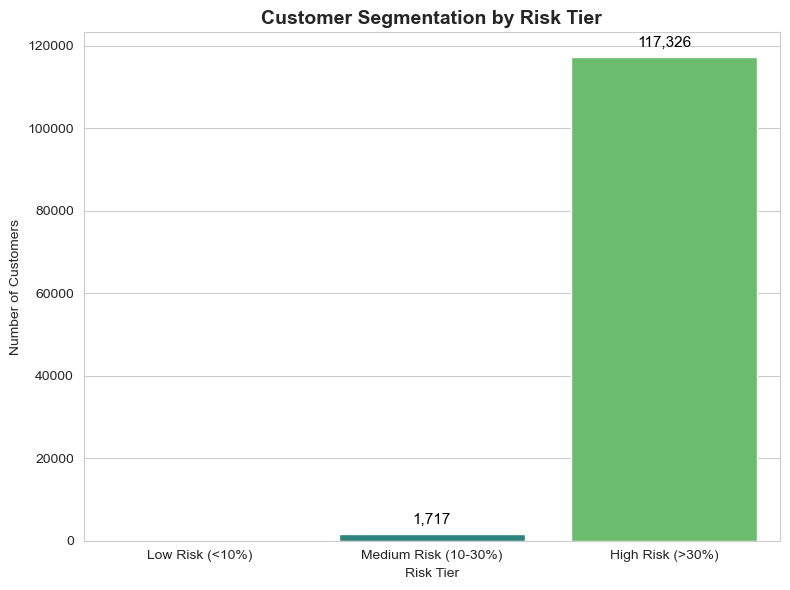

In [12]:

plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")

# Categorize customers into Risk Tiers based on probability
viz_df['Risk_Tier'] = pd.cut(viz_df['Probability'], 
                             bins=[0, 0.10, 0.30, 1.0], 
                             labels=['Low Risk (<10%)', 'Medium Risk (10-30%)', 'High Risk (>30%)'])

ax = sns.countplot(data=viz_df, x='Risk_Tier', palette='viridis')

plt.title('Customer Segmentation by Risk Tier', fontsize=14, fontweight='bold')
plt.xlabel('Risk Tier')
plt.ylabel('Number of Customers')

# Adding exact counts on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

### **Graph 2 Interpretation: Risk Tier Segmentation**

This bar chart categorizes the customer base into rigid Risk Tiers based on absolute thresholds (<10%, 10-30%, and >30%). As established in Graph 1, the balanced model adjusted the overall probability scores higher. Consequently, virtually the entire test set (117,326 customers) was pushed into the >30% bracket, leaving only 1,717 in the Medium Risk tier. 

**Business Takeaway:** While the model successfully ranks customers from lowest to highest risk, absolute probability thresholds of 10% and 30% are no longer appropriate for this balanced output. To create actionable marketing segments, the business should re-calibrate these tiers based on the new distribution curve—for example, treating the bottom 33% of the distribution as the new "Low Risk" segment for ad campaigns.

### ** Strategic Suggestions to Drive Customer Conversion**

By leveraging the model's probability rankings, the marketing team can implement targeted strategies to maximize customer acquisition without taking on unprofitable risk.

**1. Strategies for the Lowest-Risk Segment (The Left Side of the Curve):**
These customers have the lowest probability of claiming. The goal is to maximize their conversion rates at all costs.
* **Aggressive Introductory Pricing:** Offer steep "safe driver" or "low risk" discounts to undercut competitor quotes. Because their expected claim cost is near zero, the business can afford tighter profit margins to secure their purchase.
* **Frictionless Onboarding:** Remove barriers to entry. Offer these customers "instant approval" quotes with minimal required paperwork, making it incredibly easy for them to click "buy" before shopping elsewhere.

**2. Strategies for the Highest-Risk Segment (The Right Side of the Curve):**
These customers have the highest probability of filing a claim. The strategy here shifts from "acquire at all costs" to "acquire only if profitable."
* **Value-Added Safety Features:** Instead of competing on price to win these customers, bundle policies with safety technology. For example, offer a free "telematics device" (a driving tracker) that promises future discounts for good behavior. This attracts customers willing to improve and helps mitigate the company's risk.
* **Tiered Premium Plans:** Present these customers with policies that have higher deductibles or slightly elevated premiums. This ensures that when they buy the product, the company has collected enough upfront capital to offset their statistically probable claim payouts.

**3. General Marketing Optimization:**
* **Lookalike Audiences:** The marketing team should feed the profiles of the "Lowest-Risk" customers into digital advertising algorithms (like Google Ads or Meta Ads). By telling the algorithm to find "more people like this," the company ensures its ad budget is spent exclusively on acquiring the most profitable demographic possible.

### **Model Comparison Report**

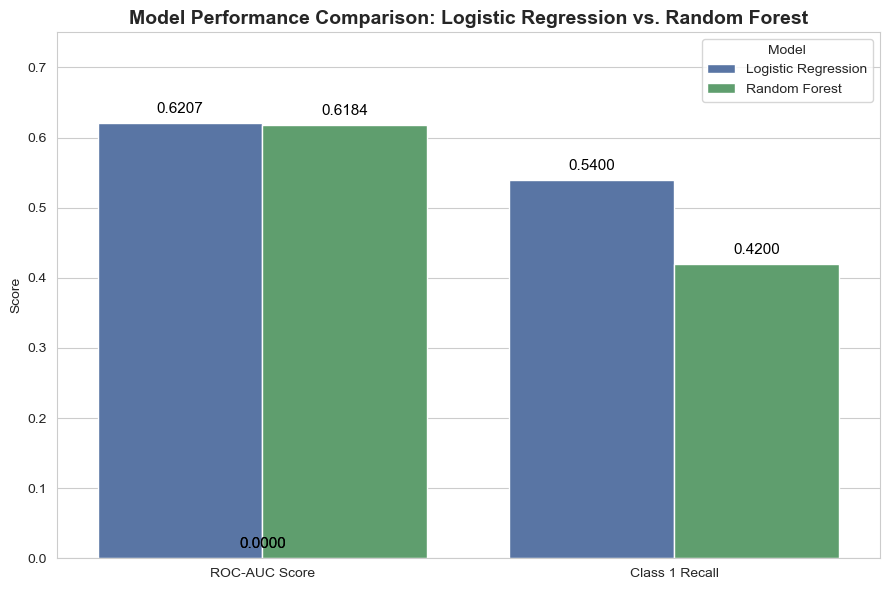

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Creating a dataframe with our evaluation metrics
metrics_data = {
    'Model': ['Logistic Regression', 'Logistic Regression', 'Random Forest', 'Random Forest'],
    'Metric': ['ROC-AUC Score', 'Class 1 Recall', 'ROC-AUC Score', 'Class 1 Recall'],
    'Score': [0.6207, 0.5400, 0.6184, 0.4200]
}

df_metrics = pd.DataFrame(metrics_data)

# Setting  up the plot
plt.figure(figsize=(9, 6))
sns.set_style("whitegrid")

# Creating a grouped bar chart
ax = sns.barplot(data=df_metrics, x='Metric', y='Score', hue='Model', palette=['#4C72B0', '#55A868'])

plt.title('Model Performance Comparison: Logistic Regression vs. Random Forest', fontsize=14, fontweight='bold')
plt.ylim(0, 0.75) # Gives room for the data labels on top
plt.ylabel('Score')
plt.xlabel('')

# Adding exact score labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5), 
                textcoords='offset points')

plt.legend(title='Model', loc='upper right')
plt.tight_layout()
plt.show()

**Overview:**
To address the problem statement, two predictive models—Logistic Regression (Baseline) and Random Forest (Advanced Ensemble)—were trained to predict the probability of an insurance claim. Because the dataset suffers from an extreme class imbalance (96.3% of customers do not claim, while 3.6% do), standard accuracy was discarded as an evaluation metric. Instead, the models were evaluated using the **ROC-AUC Score** and **Minority Class Recall** (the ability to correctly identify the 3.6% who actually make a claim). Both models utilized balanced class weights during training.

**Performance Breakdown:**
As illustrated in the chart:
* **Logistic Regression** achieved an ROC-AUC Score of **0.6207** and a Class 1 Recall of **0.5400**.
* **Random Forest** achieved an ROC-AUC Score of **0.6184** and a Class 1 Recall of **0.4200**.

**Recommendation for Production:**
**Logistic Regression** is the recommended model for production. While the ROC-AUC scores are relatively similar, the visual comparison clearly demonstrates that Logistic Regression significantly outperforms Random Forest in identifying the minority class (Recall). By successfully capturing 54% of actual claimants compared to Random Forest's 42%, the Logistic Regression model proves to be vastly more effective at flagging high-risk customers, which is the primary business objective for the marketing team.

### **Report on Challenges Faced and Techniques Used**

During the development of this predictive model, several significant data challenges were encountered. Below is an outline of these challenges and the specific techniques used to resolve them:

**Challenge 1: Hidden Missing Data**
* **The Issue:** Initial data inspection using standard null-value checks (`df.isnull().sum()`) incorrectly indicated that the dataset was perfectly clean with zero missing values. However, deeper inspection revealed that missing values were intentionally encoded as `-1`.
* **The Technique:** All `-1` values were converted to standard `NaN` to allow Pandas and Scikit-Learn to process them correctly. Two columns (`ps_car_03_cat` and `ps_car_05_cat`) were found to have massive amounts of missing data (over 40% and 60% respectively) and were dropped entirely to prevent them from skewing the model. For the remaining columns, **Median Imputation** was applied. The median was chosen over the mean because it is highly robust against outliers, ensuring the statistical distribution of the anonymized features remained stable.

**Challenge 2: Extreme Class Imbalance**
* **The Issue:** The target variable was exceptionally imbalanced, with roughly 96.3% of customers falling into Class 0 (No Claim) and only 3.6% in Class 1 (Claim). If left unaddressed, a machine learning model would simply predict "0" every time, achieving 96% accuracy while being completely useless for the business goal of identifying claimants.
* **The Technique:** To force the models to learn the patterns of the minority class, `class_weight='balanced'` was implemented during model training. This technique heavily penalizes the algorithm for misclassifying actual claimants. Furthermore, standard "Accuracy" was discarded as an evaluation metric. Instead, the models were evaluated using the **ROC-AUC Score** and **Minority Class Recall**, ensuring the final model was genuinely capable of distinguishing between high-risk and low-risk profiles.

**Challenge 3: Anonymized Features**
* **The Issue:** Due to privacy concerns, all 59 features were heavily anonymized (e.g., `ps_ind_01`, `ps_car_11`), making domain-specific feature engineering impossible.
* **The Technique:** Because manual feature creation was restricted, the strategy shifted heavily toward algorithm selection and statistical scaling. A **StandardScaler** was applied to normalize the distributions, ensuring that distance-based calculations within the Logistic Regression model were not disproportionately weighted by features with naturally larger numeric ranges.